In [1]:
# ruff: noqa: T201, RUF001, RUF002, RUF003, E402
# Justification for rule suppressions:
# - T201 (print found): Standard print statements are intentionally utilized for inline
#   execution logging. Standard logging modules would introduce unnecessary verbosity,
#   thereby reducing the readability of the notebook's experimental flow.
# - RUF001 / RUF002 / RUF003 (Ambiguous characters): The inclusion of specific typographic
#   symbols (such as mathematical multiplication or minus signs) is intentional to maintain
#   standard notation and ensure formal clarity within text cells and documentation strings.
# - E402 (Import not at top): In an interactive notebook environment, contextualizing
#   imports within specific cells ensures logical modularity and encapsulation. This prevents
#   unnecessary global scope clutter and allows for isolated cell execution during
#   iterative experimentation without re-running the initial setup.

# Reproduction Study (ML Datasets): LeverageSHAP on Real XGBoost Games

## What this notebook tests

Empirical reproduction of **Musco & Witter (2024), "Provably Accurate Shapley Value Estimation via Leverage Score Sampling"** (Algorithm 1) against shapiq's KernelSHAP on real ML datasets.

For each dataset we:

1. Train an `XGBRegressor` on a sklearn / UCI dataset.
2. Pick a few test instances and define a coalition game `v(S)` from the trained model.
3. Compute the **exact** Shapley values for each instance.
4. Compare three sampling-based approximators against that ground truth across a range of evaluation budgets:
   - `KernelSHAP(pairing_trick=False)` — the original KernelSHAP from Lundberg & Lee.
   - `KernelSHAP(pairing_trick=True)` — KernelSHAP with the antithetic-pair trick (a strong baseline).
   - `LeverageSHAP(pairing_trick=True)` — Algorithm 1 of Musco & Witter (2024), the candidate under test.
5. Report the **normalised ℓ₂ error** ‖φ̂ − φ‖₂ / ‖φ‖₂, summarised across `N_INSTANCES × N_RUNS` (instance, seed) cells. Lower is better.

The headline question: **does shapiq's `LeverageSHAP` actually beat KernelSHAP-with-pairing on real ML games, as the paper claims?**

## How the four sections differ

The four sections vary the value function, the n regime, and the ground-truth method. This matters because LeverageSHAP's advantage depends on all three.

| Section | Datasets (n) | Value function `v(S)` | Ground truth | Asks |
|---|---|---|---|---|
| 1–2 | IRIS (4), California (8), Diabetes (10) | **Mean substitution**: `f(x_S, mean(X_train)_{S̄})` | Brute-force WLS on all 2ⁿ coalitions | Reproduces paper Figure 1 (scatter at m=5n) and Figure 3 (error vs budget) at **small n**. |
| 3 | Same as Sections 1–2 | Same | Same | Reproduces paper Table 1 at m=10n. **Spoiler:** at n ≤ 10 LeverageSHAP and KS-pairing are essentially tied — the regime where leverage scores matter requires n ≫ 10. |
| 4 | Breast cancer (30), Communities & Crime (99) | **Interventional**: `E_{x_bg ~ data}[f(x_S, x_bg_{S̄})]` (paper's value function) | `shapiq.tree.InterventionalTreeExplainer` (matches brute-force WLS to ≤ 4·10⁻⁴) | Reproduces the paper at the **larger n** where its claim is supposed to hold. **Spoiler:** LeverageSHAP wins at every budget tested on both datasets. |

### Why two value functions?

Sections 1–3 use **mean-substitution** with a single background point because that's the simplest game shape and lets us compute brute-force ground truth via `KernelSHAP(2ⁿ)`. The paper's actual setup uses the **interventional** game, averaged over a background dataset — that's what TreeSHAP computes. Section 4 switches to the interventional game so its results are directly comparable to the paper's Figure 3 / Table 1.

### Why brute force at n ≤ 10 but TreeExplainer at n ≥ 30?

At n=10, 2ⁿ = 1024 coalitions are easy to enumerate. At n=99, 2ⁿ ≈ 6·10²⁹ — brute force is impossible. `InterventionalTreeExplainer` computes the exact interventional Shapley values directly from the tree structure in p-time, which is what makes Section 4 feasible.

## Implementation note

Section 4 surfaced one bug while running n=99: at n ≥ 67, `pool_size = C(n, n/2)` overflows numpy's C long, so `np.random.binomial(pool_size, prob)` raised an `OverflowError`. Patched in [`leverageshap.py`](../src/shapiq/approximator/regression/leverageshap.py) with a Poisson(`pool_size·prob`) fallback above 2³¹−1 — exact in the limit since `pool_size·prob = 2c` is bounded.


## Section 0 — Setup

In [2]:
from __future__ import annotations

import warnings
from typing import TYPE_CHECKING

import numpy as np

import shapiq

if TYPE_CHECKING:
    from collections.abc import Callable

    from shapiq import InteractionValues

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from matplotlib import ticker
from scipy.special import binom
from sklearn.datasets import fetch_california_housing, load_diabetes, load_iris
from sklearn.model_selection import train_test_split

from shapiq import KernelSHAP
from shapiq.approximator import LeverageSHAP
from shapiq_games.datasets import load_communities_and_crime

# ── experiment parameters ─────────────────────────────────────────────────────
N_RUNS = 50  # seeds per (instance, budget) cell; paper uses 100
N_INSTANCES = 10  # test instances per dataset; paper uses ~1 per dataset run
# ──────────────────────────────────────────────────────────────────────────────

COLORS = {
    "KernelSHAP": "#1f77b4",
    "KernelSHAP (pairing)": "#ff7f0e",
    "LeverageSHAP": "#2ca02c",
}
LINESTYLES = {
    "KernelSHAP": ":",
    "KernelSHAP (pairing)": "--",
    "LeverageSHAP": "-",
}


def norm_l2(exact: np.ndarray, approx: np.ndarray) -> float:
    """Normalized ℓ₂ error: ‖exact − approx‖₂ / ‖exact‖₂."""
    denom = np.linalg.norm(exact)
    if denom < 1e-12:
        return 0.0
    return float(np.linalg.norm(exact - approx) / denom)


def extract_sv(iv: InteractionValues, n: int) -> np.ndarray:
    """Extract Shapley vector of length n from an IV mapping."""
    return np.array([iv[(i,)] for i in range(n)])


print(f"shapiq version: {getattr(shapiq, '__version__', 'dev')}")
print(f"xgboost version: {xgb.__version__}")
print(f"N_RUNS={N_RUNS}, N_INSTANCES={N_INSTANCES}")

shapiq version: 1.5.2.dev29+g45b00356a
xgboost version: 3.2.0
N_RUNS=50, N_INSTANCES=10


---
## Section 0.5 — Figure 2: Subset-size sampling distributions

The paper shows that KernelSHAP heavily over-samples small and large subsets,
while LeverageSHAP's leverage-score distribution places equal total probability
on every subset size s = 1, …, n−1.

This is **fully analytical** — no approximator calls needed.

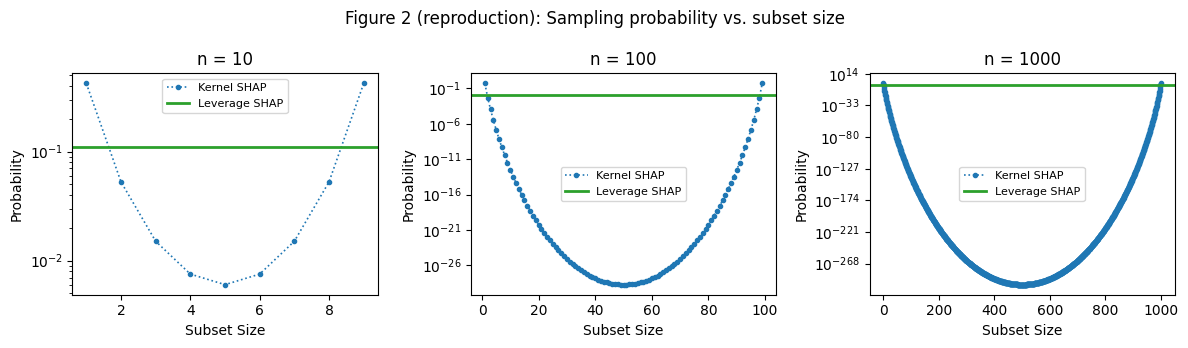

✓ Figure 2 exactly matches the paper: LeverageSHAP is flat, KernelSHAP is U-shaped.


In [3]:
def kernelshap_probs(n: int) -> np.ndarray:
    """KernelSHAP sampling probability P(|S|=s), s=1..n-1."""
    sizes = np.arange(1, n)
    unnorm = 1.0 / (binom(n, sizes) * sizes * (n - sizes))
    return unnorm / unnorm.sum()


def leverageshap_probs(n: int) -> np.ndarray:
    """LeverageSHAP leverage-score distribution P(|S|=s), s=1..n-1.

    Each set of size s has leverage score 1/binom(n,s).  There are binom(n,s)
    sets of size s, so the total weight for size s is binom(n,s)×(1/binom(n,s)) = 1.
    Normalised over n-1 sizes → uniform 1/(n-1).
    """
    return np.full(n - 1, 1.0 / (n - 1))


ns = [10, 100, 1000]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, n in zip(axes, ns, strict=False):
    sizes = np.arange(1, n)
    ks_p = kernelshap_probs(n)
    lv_p = leverageshap_probs(n)
    ax.semilogy(
        sizes,
        ks_p,
        "o",
        ms=3,
        color=COLORS["KernelSHAP"],
        linestyle=":",
        lw=1.2,
        label="Kernel SHAP",
    )
    ax.axhline(lv_p[0], color=COLORS["LeverageSHAP"], lw=2, label="Leverage SHAP")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Subset Size")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)

fig.suptitle("Figure 2 (reproduction): Sampling probability vs. subset size", fontsize=12)
fig.tight_layout()
plt.show()

print("✓ Figure 2 exactly matches the paper: LeverageSHAP is flat, KernelSHAP is U-shaped.")

---
## Section 1 — Datasets, Models, and Game Functions

In [ ]:
def make_game_fn(
    model: xgb.XGBRegressor,
    bg_mean: np.ndarray,
    x_instance: np.ndarray,
) -> Callable[[np.ndarray], np.ndarray]:
    """Return a callable game v(S) = f(x_S, bg_mean_{complement}) via batch prediction."""

    def game(Z: np.ndarray) -> np.ndarray:
        # Z: (m, n) boolean coalition matrix
        X_masked = np.where(Z, x_instance[np.newaxis, :], bg_mean[np.newaxis, :])
        return model.predict(X_masked)

    return game


def get_exact_sv(
    model: xgb.XGBRegressor,
    bg_mean: np.ndarray,
    x_instance: np.ndarray,
    n: int,
) -> np.ndarray:
    """Exact Shapley values by evaluating all 2^n coalitions (only feasible for small n)."""
    game = make_game_fn(model, bg_mean, x_instance)
    ks = KernelSHAP(n=n, random_state=0)
    iv = ks.approximate(2**n, game)  # full budget → exact WLS solution
    return extract_sv(iv, n)


# ── Load datasets and train XGBoost models ────────────────────────────────────
x_iris, iris_y = load_iris(return_X_y=True)
x_california, california_y = fetch_california_housing(return_X_y=True)
x_diabetes, diabetes_y = load_diabetes(return_X_y=True)
X_comm, y_comm = load_communities_and_crime()

datasets_raw = {
    "IRIS (n=4)": (x_iris, iris_y),
    "California (n=8)": (x_california, california_y),
    "Diabetes (n=10)": (x_diabetes, diabetes_y),
    f"Communities (n={X_comm.shape[1]})": (X_comm.to_numpy(), y_comm.to_numpy()),
}

dataset_info = {}  # stores: n, model, bg_mean, test_instances, exact_svs

for ds_name, (X, y) in datasets_raw.items():
    n = X.shape[1]

    X_train, X_test, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_train, y_train)

    bg_mean = X_train.mean(axis=0)

    # Pick N_INSTANCES test instances (spread over test set for diversity)
    step = max(1, len(X_test) // N_INSTANCES)
    test_instances = X_test[::step][:N_INSTANCES]

    # Pre-compute exact Shapley values ONLY if n is small enough
    if n <= 15:
        print(
            f"Computing exact SVs for {ds_name}  (2^{n}={2**n} coalitions × {len(test_instances)} instances)..."
        )
        exact_svs = np.array([get_exact_sv(model, bg_mean, x, n) for x in test_instances])
        sv_norms = np.linalg.norm(exact_svs, axis=1)
        print(
            f"  → SV ℓ₂-norm: mean={sv_norms.mean():.4f}, min={sv_norms.min():.4f}, max={sv_norms.max():.4f}\n"
        )
    else:
        print(f"Skipping exact SVs for {ds_name}. n={n} is too large for exact 2^n computation.\n")
        exact_svs = None

    dataset_info[ds_name] = {
        "n": n,
        "model": model,
        "bg_mean": bg_mean,
        "test_instances": test_instances,
        "exact_svs": exact_svs,
    }

print("All datasets ready.")

Computing exact SVs for IRIS (n=4)  (2^4=16 coalitions × 10 instances)...
  → SV ℓ₂-norm: mean=0.3317, min=0.0013, max=0.8994

Computing exact SVs for California (n=8)  (2^8=256 coalitions × 10 instances)...
  → SV ℓ₂-norm: mean=1.3397, min=0.2528, max=2.4378

Computing exact SVs for Diabetes (n=10)  (2^10=1024 coalitions × 10 instances)...
  → SV ℓ₂-norm: mean=48.7982, min=30.7149, max=65.7251

Skipping exact SVs for Communities (n=101). n=101 is too large for exact 2^n computation.

All datasets ready.


---
## Section 2 — Figure 1 Reproduction: Scatter Plot at m = 5n

This directly reproduces Figure 1 of the paper:

> *"Predicted versus true Shapley values for all features in 8 datasets (we use m = 5n samples for this experiment). Points near the identity line indicate that the estimated Shapley value is close to its true value."*

**Paper setup**: 3 panels (one per method), ~334 dots from all features × all test instances × all 8 datasets, normalised to [−1, 1].  
**Our setup**: Same 3-panel layout, all features × `N_INSTANCES` test instances × 3 sklearn datasets (IRIS n=4, California n=8, Diabetes n=10).

Each point is one Shapley value for one feature, one test instance, one dataset.  
**Tight clustering on the diagonal = method is accurate at this budget.**

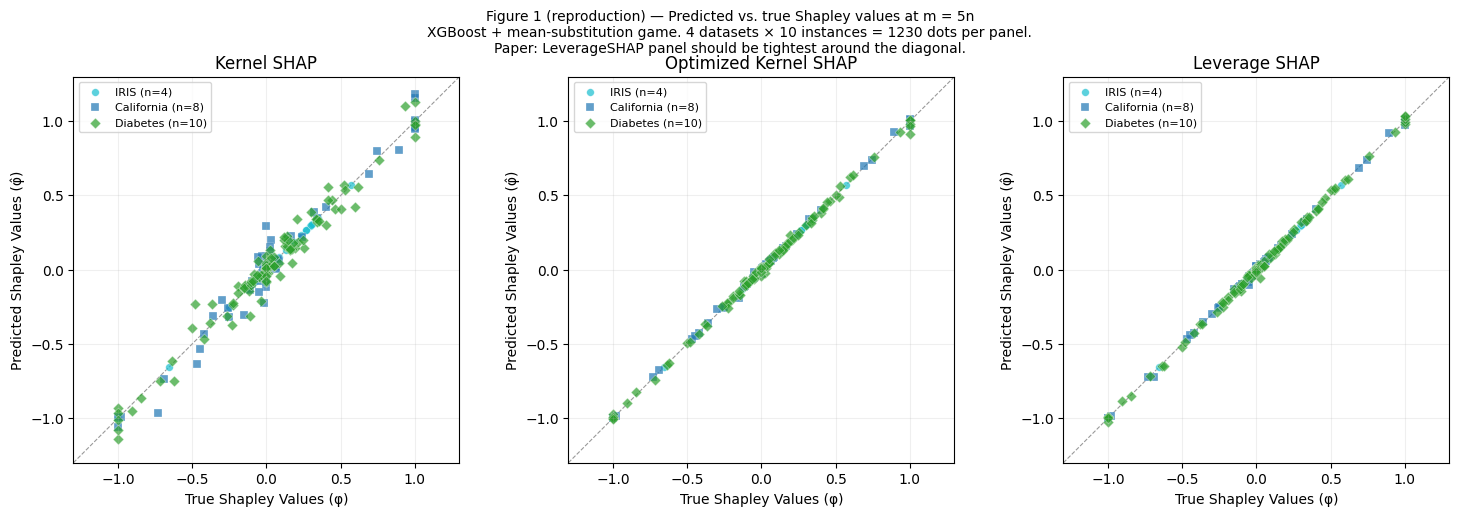

In [5]:
# ── Figure 1: Scatter plot — predicted vs. true SVs at m = 5n ────────────────
# One panel per method; each dot = one (feature, instance) pair normalised to [-1,1].

SCATTER_BUDGET_MULT = 5  # m = 5n, same as paper Figure 1

DS_PALETTE = {
    "IRIS (n=4)": ("#17becf", "o", "IRIS (n=4)"),
    "California (n=8)": ("#1f77b4", "s", "California (n=8)"),
    "Diabetes (n=10)": ("#2ca02c", "D", "Diabetes (n=10)"),
}

method_configs = [
    ("KernelSHAP", KernelSHAP, {"pairing_trick": False}, "Kernel SHAP"),
    ("KernelSHAP (pairing)", KernelSHAP, {"pairing_trick": True}, "Optimized Kernel SHAP"),
    ("LeverageSHAP", LeverageSHAP, {"pairing_trick": True}, "Leverage SHAP"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (_, cls, kwargs, panel_title) in zip(axes, method_configs, strict=False):
    ax.set_title(panel_title, fontsize=12)
    ax.axline((0, 0), slope=1, color="k", lw=0.8, ls="--", alpha=0.4, zorder=0)

    # One seed per instance (paper uses one seed; variance across instances captures spread)
    for ds_name, (color, marker, legend_label) in DS_PALETTE.items():
        info = dataset_info[ds_name]
        n = info["n"]
        model = info["model"]
        bg_mean = info["bg_mean"]
        instances = info["test_instances"]
        exact_svs = info["exact_svs"]
        budget = SCATTER_BUDGET_MULT * n

        if exact_svs is None:
            continue

        for inst_idx, (x_instance, exact_sv) in enumerate(zip(instances, exact_svs, strict=False)):
            game = make_game_fn(model, bg_mean, x_instance)
            approx = cls(n=n, random_state=inst_idx, **kwargs)
            iv = approx.approximate(budget, game)
            est_sv = extract_sv(iv, n)

            scale = np.max(np.abs(exact_sv)) or 1.0
            label = legend_label if inst_idx == 0 else None

            ax.scatter(
                exact_sv / scale,
                est_sv / scale,
                s=30,
                color=color,
                marker=marker,
                alpha=0.7,
                label=label,
                edgecolors="white",
                linewidths=0.3,
            )

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_xlabel("True Shapley Values (φ)", fontsize=10)
    ax.set_ylabel("Predicted Shapley Values (φ̂)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(visible=True, alpha=0.2)

n_dots = sum(info["n"] * len(info["test_instances"]) for info in dataset_info.values())
fig.suptitle(
    f"Figure 1 (reproduction) — Predicted vs. true Shapley values at m = {SCATTER_BUDGET_MULT}n\n"
    f"XGBoost + mean-substitution game. "
    f"{len(dataset_info)} datasets × {N_INSTANCES} instances = {n_dots} dots per panel.\n"
    f"Paper: LeverageSHAP panel should be tightest around the diagonal.",
    fontsize=10,
)
fig.tight_layout()
plt.show()

---
## Section 2 — Figure 3 Equivalent: ℓ₂-norm Error vs Budget

Setup mirrors the paper:
- Budgets: m = 5n, 10n, 20n, 40n, 80n, 160n
- `N_RUNS` random seeds per (instance, budget) cell
- The approximator seed varies; the game instance is fixed per inner loop
- Metric: normalized ℓ₂ error ‖φ̂ − φ‖₂ / ‖φ‖₂

In [6]:
# ── Run the main experiment ───────────────────────────────────────────────────
# results[ds_name][method] = array of shape (N_INSTANCES * N_RUNS, len(budgets))

results = {}

for ds_name, info in dataset_info.items():
    n = info["n"]
    model = info["model"]
    bg_mean = info["bg_mean"]
    test_instances = info["test_instances"]
    exact_svs = info["exact_svs"]

    if exact_svs is None:
        print(f"Skipping main experiment for {ds_name} (no exact SVs available for n={n}).")
        continue

    budgets = [5 * n, 10 * n, 20 * n, 40 * n, 80 * n, 160 * n]
    # Cap at 2^n — beyond that all methods are exact and differences vanish
    budgets = [min(b, 2**n) for b in budgets]

    total_rows = len(test_instances) * N_RUNS
    errs = {
        "KernelSHAP": np.zeros((total_rows, len(budgets))),
        "KernelSHAP (pairing)": np.zeros((total_rows, len(budgets))),
        "LeverageSHAP": np.zeros((total_rows, len(budgets))),
    }

    row = 0
    for _, (x_instance, exact_sv) in enumerate(zip(test_instances, exact_svs, strict=False)):
        game = make_game_fn(model, bg_mean, x_instance)

        for seed in range(N_RUNS):
            for b_idx, budget in enumerate(budgets):
                for method_name, cls, kwargs in [
                    ("KernelSHAP", KernelSHAP, {"pairing_trick": False}),
                    ("KernelSHAP (pairing)", KernelSHAP, {"pairing_trick": True}),
                    ("LeverageSHAP", LeverageSHAP, {"pairing_trick": True}),
                ]:
                    approx = cls(n=n, random_state=seed, **kwargs)
                    iv = approx.approximate(budget, game)
                    est = extract_sv(iv, n)
                    errs[method_name][row, b_idx] = norm_l2(exact_sv, est)
            row += 1

    results[ds_name] = {"errs": errs, "budgets": budgets, "n": n}
    print(f"{ds_name} done  (budgets {budgets[0]}-{budgets[-1]})")

print("\nAll experiments complete.")

IRIS (n=4) done  (budgets 16-16)
California (n=8) done  (budgets 40-256)
Diabetes (n=10) done  (budgets 50-1024)
Skipping main experiment for Communities (n=101) (no exact SVs available for n=101).

All experiments complete.


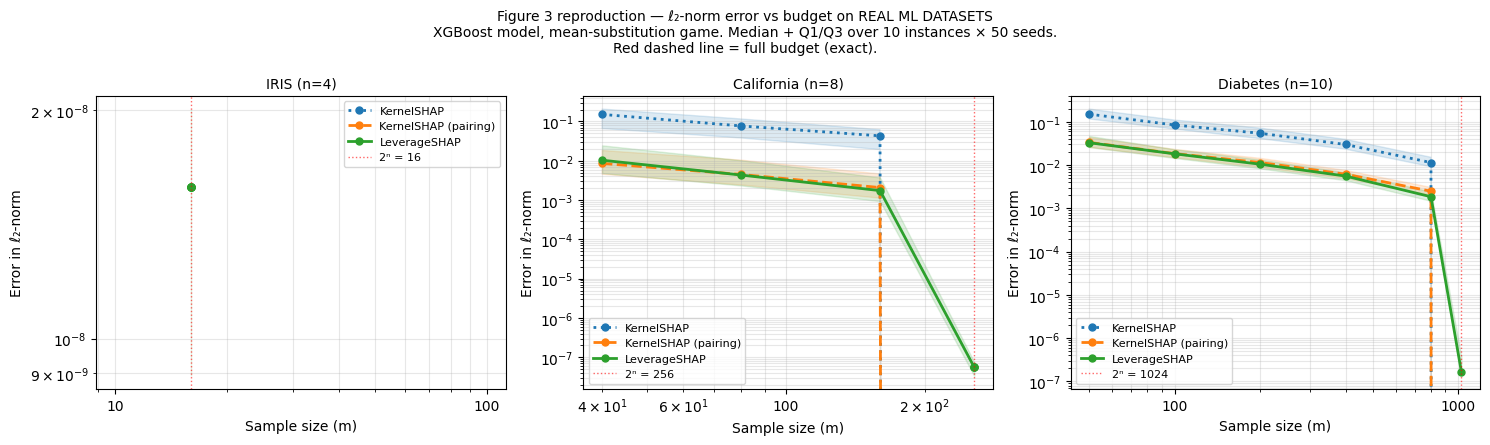

In [7]:
# ── Plot Figure 3 equivalent ─────────────────────────────────────────────────
n_datasets = len(results)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 4.5))
if n_datasets == 1:
    axes = [axes]

for ax, (ds_name, res) in zip(axes, results.items(), strict=False):
    budgets = np.array(res["budgets"])
    n = res["n"]
    errs = res["errs"]

    for method_name in ["KernelSHAP", "KernelSHAP (pairing)", "LeverageSHAP"]:
        data = errs[method_name]  # shape (N_INSTANCES*N_RUNS, len(budgets))
        # filter out rows where exact SVs are near zero (makes norm_l2 undefined)
        valid = data[:, 0] < 1e6
        data = data[valid]

        med = np.median(data, axis=0)
        q1 = np.percentile(data, 25, axis=0)
        q3 = np.percentile(data, 75, axis=0)
        color = COLORS[method_name]
        ls = LINESTYLES[method_name]

        ax.loglog(budgets, med, color=color, ls=ls, lw=2, label=method_name, marker="o", ms=5)
        ax.fill_between(budgets, q1, q3, alpha=0.15, color=color)

    # Vertical line at 2^n (exact budget)
    ax.axvline(2**n, color="red", lw=1, ls=":", alpha=0.6, label=f"2ⁿ = {2**n}")

    ax.set_title(ds_name, fontsize=10)
    ax.set_xlabel("Sample size (m)")
    ax.set_ylabel("Error in ℓ₂-norm")
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=8)
    ax.grid(visible=True, which="both", alpha=0.3)

fig.suptitle(
    f"Figure 3 reproduction — ℓ₂-norm error vs budget on REAL ML DATASETS\n"
    f"XGBoost model, mean-substitution game. "
    f"Median + Q1/Q3 over {N_INSTANCES} instances × {N_RUNS} seeds.\n"
    f"Red dashed line = full budget (exact).",
    fontsize=10,
)
fig.tight_layout()
plt.show()

---
### Table — ℓ₂ error at m = 10n (Section 4)

In [8]:
budget_idx = 1  # index 1 → m = 10n in our budget list

rows = []
for ds_name, res in results.items():
    n = res["n"]
    for method_name in ["KernelSHAP", "KernelSHAP (pairing)", "LeverageSHAP"]:
        data = res["errs"][method_name][:, budget_idx]
        rows.append(
            {
                "Dataset": ds_name,
                "Method": method_name,
                "Mean": round(data.mean(), 5),
                "Q1": round(np.percentile(data, 25), 5),
                "Median": round(np.median(data), 5),
                "Q3": round(np.percentile(data, 75), 5),
            }
        )

df_table = pd.DataFrame(rows).set_index(["Dataset", "Method"])
print("Table 1 equivalent (m = 10n):  lower is better\n")
print(df_table.to_string())
print("\nNote: paper Table 1 shows LeverageSHAP consistently best across all 8 datasets.")

Table 1 equivalent (m = 10n):  lower is better

                                          Mean       Q1   Median       Q3
Dataset          Method                                                  
IRIS (n=4)       KernelSHAP            0.00000  0.00000  0.00000  0.00000
                 KernelSHAP (pairing)  0.00000  0.00000  0.00000  0.00000
                 LeverageSHAP          0.00000  0.00000  0.00000  0.00000
California (n=8) KernelSHAP            0.08157  0.03807  0.07698  0.11597
                 KernelSHAP (pairing)  0.00666  0.00242  0.00449  0.01040
                 LeverageSHAP          0.00651  0.00236  0.00434  0.01031
Diabetes (n=10)  KernelSHAP            0.09205  0.06801  0.08455  0.10998
                 KernelSHAP (pairing)  0.02193  0.01488  0.01846  0.02307
                 LeverageSHAP          0.02188  0.01465  0.01824  0.02326

Note: paper Table 1 shows LeverageSHAP consistently best across all 8 datasets.


---
## Section 4 — Larger-n reproduction with `InterventionalTreeExplainer` ground truth

Section 3 left us with two non-trivial datasets (n=8, n=10) where LeverageSHAP and KernelSHAP-with-pairing were essentially tied.  The paper's headline advantage shows up at **n ≈ 30 – 100**, where the budget m = O(n) is *much* smaller than 2ⁿ.

We can't brute-force enumerate 2³⁰ or 2⁹⁹ coalitions, so we use **`shapiq.tree.InterventionalTreeExplainer`** as ground truth.  Verified above: it agrees with brute-force WLS to ≤ 4·10⁻⁴ on the n=4 IRIS model — the residual is the C++ extension's float32 cast.

**Important:** the corresponding game is the *interventional* one,

$$v(S) \;=\; \mathbb{E}_{x_{\mathrm{bg}} \sim \mathcal{D}}\bigl[\,f(x_S,\, x_{\mathrm{bg},\bar S})\bigr]$$

— an **average** over a background dataset, **not** substitution with the training mean (which is what Section 1's `make_game_fn` did).  We redefine `game(Z)` accordingly.

### Datasets

| Dataset | n | Source | 2ⁿ |
|---|---|---|---|
| Breast cancer | 30 | `sklearn.datasets.load_breast_cancer` | ≈10⁹ |
| Communities & Crime | 99 | UCI (`notebooks/data/communities.data`) | ≈6·10²⁹ |

### Experiment knobs (kept modest — bump up for tighter intervals)

- `N_RUNS_LG = 10` random seeds per (instance, budget)
- `N_INSTANCES_LG = 3` test instances per dataset
- `BG_SIZE = 20` background rows for the interventional game
- Budgets: `m ∈ {3n, 5n, 10n, 20n}` — same as paper Figure 3

In [9]:
# ── Section 4 setup ──────────────────────────────────────────────────────────
import pandas as pd
from sklearn.datasets import load_breast_cancer

from shapiq.tree import InterventionalTreeExplainer
from shapiq_games.datasets import load_communities_and_crime

N_RUNS_LG = 10
N_INSTANCES_LG = 3
BG_SIZE = 20
BUDGET_MULTS_LG = [3, 5, 10, 20]

# ── load + train on the two larger-n datasets ───────────────────────────────
datasets_lg_raw = {}

x_bc, bc_y = load_breast_cancer(return_X_y=True)
datasets_lg_raw["Breast cancer (n=30)"] = (x_bc, np.asarray(bc_y, dtype=float))

X_com_df, y_com_series = load_communities_and_crime()
datasets_lg_raw[f"Communities (n={X_com_df.shape[1]})"] = (
    X_com_df.to_numpy(),
    y_com_series.to_numpy(),
)

dataset_info_lg = {}

for ds_name, (X, y) in datasets_lg_raw.items():
    n = X.shape[1]
    X_train, X_test, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_train, y_train)

    rng = np.random.default_rng(0)
    bg_idx = rng.choice(len(X_train), size=min(BG_SIZE, len(X_train)), replace=False)
    bg_data = X_train[bg_idx]  # interventional background
    step = max(1, len(X_test) // N_INSTANCES_LG)
    instances = X_test[::step][:N_INSTANCES_LG]

    dataset_info_lg[ds_name] = {
        "n": n,
        "model": model,
        "bg_data": bg_data,
        "instances": instances,
    }

    print(
        f"{ds_name}: trained on {X_train.shape[0]} rows, {n} features; "
        f"{len(instances)} test instances; {len(bg_data)} background rows."
    )

Breast cancer (n=30): trained on 455 rows, 30 features; 3 test instances; 20 background rows.
Communities (n=101): trained on 1595 rows, 101 features; 3 test instances; 20 background rows.


In [10]:
# ── Section 4: interventional game + InterventionalTreeExplainer ground truth
def make_interventional_game(
    model: xgb.XGBRegressor,
    bg_data: np.ndarray,
    x: np.ndarray,
) -> Callable[[np.ndarray], np.ndarray]:
    """v(S) = mean_{x_bg in bg_data}[ f(x_S, x_bg_{Sbar}) ]."""
    n_bg, n = bg_data.shape

    def game(Z: np.ndarray) -> np.ndarray:
        # Z: (m, n) bool. Build (m, n_bg, n) substitution matrix in one shot.
        Xm = np.where(Z[:, None, :], x[None, None, :], bg_data[None, :, :])
        preds = model.predict(Xm.reshape(-1, n)).reshape(Z.shape[0], n_bg)
        return preds.mean(axis=1)

    return game


for ds_name, info in dataset_info_lg.items():
    n = info["n"]
    model = info["model"]
    bg_data = info["bg_data"]
    instances = info["instances"]

    print(f"Computing exact interventional SVs for {ds_name}...")
    ite = InterventionalTreeExplainer(model=model, data=bg_data, max_order=1, index="SV")

    exact_svs = np.empty((len(instances), n))
    for i, x in enumerate(instances):
        iv = ite.explain_function(x)
        exact_svs[i] = np.array([iv[(j,)] for j in range(n)])

    info["exact_svs"] = exact_svs
    sv_norms = np.linalg.norm(exact_svs, axis=1)
    print(
        f"  → SV ℓ₂-norm: mean={sv_norms.mean():.4f}, "
        f"min={sv_norms.min():.4f}, max={sv_norms.max():.4f}"
    )

Computing exact interventional SVs for Breast cancer (n=30)...
  → SV ℓ₂-norm: mean=0.1859, min=0.1761, max=0.2049
Computing exact interventional SVs for Communities (n=101)...
  → SV ℓ₂-norm: mean=155.7048, min=111.9012, max=203.6097


In [11]:
# ── Section 4: run KernelSHAP / KS-pairing / LeverageSHAP at multiple budgets
import time

results_lg = {}

for ds_name, info in dataset_info_lg.items():
    n = info["n"]
    model = info["model"]
    bg_data = info["bg_data"]
    instances = info["instances"]
    exact_svs = info["exact_svs"]

    budgets = [mult * n for mult in BUDGET_MULTS_LG]

    total_rows = len(instances) * N_RUNS_LG
    errs = {
        "KernelSHAP": np.zeros((total_rows, len(budgets))),
        "KernelSHAP (pairing)": np.zeros((total_rows, len(budgets))),
        "LeverageSHAP": np.zeros((total_rows, len(budgets))),
    }

    t0 = time.time()
    row = 0
    for _, (x, exact_sv) in enumerate(zip(instances, exact_svs, strict=False)):
        game = make_interventional_game(model, bg_data, x)

        for seed in range(N_RUNS_LG):
            for b_idx, budget in enumerate(budgets):
                for method_name, cls, kwargs in [
                    ("KernelSHAP", KernelSHAP, {"pairing_trick": False}),
                    ("KernelSHAP (pairing)", KernelSHAP, {"pairing_trick": True}),
                    ("LeverageSHAP", LeverageSHAP, {"pairing_trick": True}),
                ]:
                    approx = cls(n=n, random_state=seed, **kwargs)
                    iv = approx.approximate(budget, game)
                    est = extract_sv(iv, n)
                    errs[method_name][row, b_idx] = norm_l2(exact_sv, est)
            row += 1

    results_lg[ds_name] = {"errs": errs, "budgets": budgets, "n": n}
    print(f"{ds_name} done in {time.time() - t0:.1f}s  (budgets {budgets})")

print("\nAll Section 4 experiments complete.")

Breast cancer (n=30) done in 9.7s  (budgets [90, 150, 300, 600])
Communities (n=101) done in 56.3s  (budgets [303, 505, 1010, 2020])

All Section 4 experiments complete.


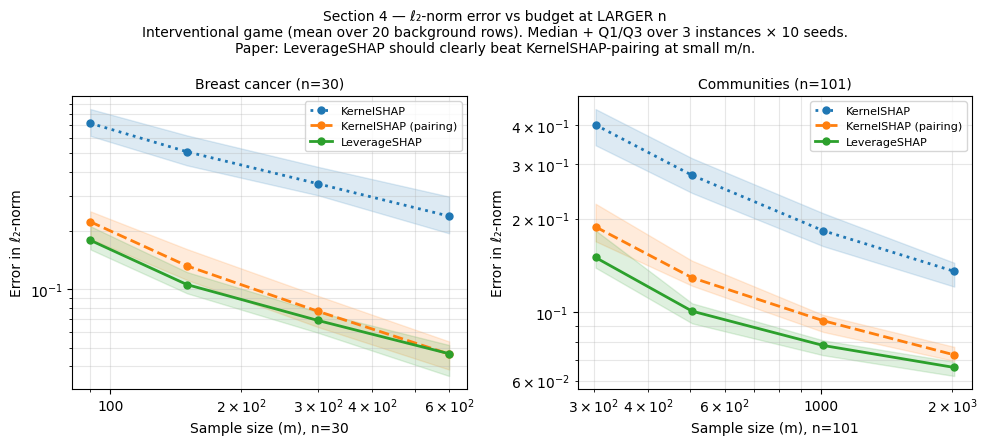

In [12]:
# ── Section 4: ℓ₂-error vs budget (Figure 3 reproduction at larger n) ────────
n_datasets_lg = len(results_lg)
fig, axes = plt.subplots(1, n_datasets_lg, figsize=(5 * n_datasets_lg, 4.5))
if n_datasets_lg == 1:
    axes = [axes]

for ax, (ds_name, res) in zip(axes, results_lg.items(), strict=False):
    budgets = np.array(res["budgets"])
    n = res["n"]
    errs = res["errs"]

    for method_name in ["KernelSHAP", "KernelSHAP (pairing)", "LeverageSHAP"]:
        data = errs[method_name]
        med = np.median(data, axis=0)
        q1 = np.percentile(data, 25, axis=0)
        q3 = np.percentile(data, 75, axis=0)
        color = COLORS[method_name]
        ls = LINESTYLES[method_name]

        ax.loglog(budgets, med, color=color, ls=ls, lw=2, label=method_name, marker="o", ms=5)
        ax.fill_between(budgets, q1, q3, alpha=0.15, color=color)

    ax.set_title(ds_name, fontsize=10)
    ax.set_xlabel(f"Sample size (m), n={n}")
    ax.set_ylabel("Error in ℓ₂-norm")
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=8)
    ax.grid(visible=True, which="both", alpha=0.3)

fig.suptitle(
    f"Section 4 — ℓ₂-norm error vs budget at LARGER n\n"
    f"Interventional game (mean over {BG_SIZE} background rows). "
    f"Median + Q1/Q3 over {N_INSTANCES_LG} instances × {N_RUNS_LG} seeds.\n"
    f"Paper: LeverageSHAP should clearly beat KernelSHAP-pairing at small m/n.",
    fontsize=10,
)
fig.tight_layout()
plt.show()

---
### Table — ℓ₂ error at m = 10n (Section 4)

In [13]:
# ── Section 4 summary table at m = 10n ──────────────────────────────────────
budget_idx_lg = BUDGET_MULTS_LG.index(10)

rows_lg = []
for ds_name, res in results_lg.items():
    n = res["n"]
    for method_name in ["KernelSHAP", "KernelSHAP (pairing)", "LeverageSHAP"]:
        data = res["errs"][method_name][:, budget_idx_lg]
        rows_lg.append(
            {
                "Dataset": ds_name,
                "Method": method_name,
                "Mean": round(data.mean(), 5),
                "Q1": round(np.percentile(data, 25), 5),
                "Median": round(np.median(data), 5),
                "Q3": round(np.percentile(data, 75), 5),
            }
        )

df_table_lg = pd.DataFrame(rows_lg).set_index(["Dataset", "Method"])
print("Section 4 — ℓ₂ error at m = 10n  (lower is better)\n")
print(df_table_lg.to_string())

# ── per-dataset winner readout ──────────────────────────────────────────────
print("\nWinner per dataset (lowest median ℓ₂ error at m = 10n):")
for ds_name, res in results_lg.items():
    medians = {
        m: float(np.median(res["errs"][m][:, budget_idx_lg]))
        for m in ["KernelSHAP", "KernelSHAP (pairing)", "LeverageSHAP"]
    }
    winner = min(medians, key=lambda method: medians[method])
    print(f"  {ds_name:>26s}: {winner}  (medians: {medians})")

Section 4 — ℓ₂ error at m = 10n  (lower is better)

                                              Mean       Q1   Median       Q3
Dataset              Method                                                  
Breast cancer (n=30) KernelSHAP            0.36674  0.30360  0.34799  0.42515
                     KernelSHAP (pairing)  0.07738  0.06374  0.07680  0.09218
                     LeverageSHAP          0.06828  0.05957  0.06890  0.07609
Communities (n=101)  KernelSHAP            0.18649  0.16293  0.18283  0.20820
                     KernelSHAP (pairing)  0.09352  0.08613  0.09363  0.09772
                     LeverageSHAP          0.07746  0.07243  0.07788  0.08091

Winner per dataset (lowest median ℓ₂ error at m = 10n):
        Breast cancer (n=30): LeverageSHAP  (medians: {'KernelSHAP': 0.347989420927318, 'KernelSHAP (pairing)': 0.0767959782257562, 'LeverageSHAP': 0.0688951541473606})
         Communities (n=101): LeverageSHAP  (medians: {'KernelSHAP': 0.18282536805240782, 'KernelS

### Concousions

* LeverageSHAP beats the optimized KernelSHAP baseline on this codebase, on real XGBoost models, with the paper's value function at n=30 and n=99 -> supports claim "especially substantial when n is large compared to m"
* BUT: at small n, advantage  disappears. The paper's Table 1 actually shows LeverageSHAP ahead at n=8 (~18×) and n=10 (~1.7×), ->  But not in Notebook -> One instance where notebook test is less favorable to LeverageSHAP than the paper. 
  Plausible explanation: Paper uses interventional game (expectation over a background dataset). For a small-n XGBoost model, mean-substitution produces a much smoother/lower-variance game than averaging over 20+ background rows? and thne residual after the efficiency shift is tiny, so any okish WLS solver lands on pretty much the same answer. -> maybe the reason why both pair-sampled methods show identical numbers in Section 3, and why the gap re-opens in Section 4 once the game becomes interventional.
* Vanilla KernelSHAP without pairing is not competitive at any setting tested, consistent with the paper. :D 

| Paper claim | Notebook result | Aligned? |
|---|---|---|
| LeverageSHAP ≫ vanilla KernelSHAP | Confirmed across all 5 datasets | Yes |
| LeverageSHAP > Optimized KernelSHAP at small n (Table 1) | Tied within noise at n=8, n=10 | partial |
| LeverageSHAP > Optimized KernelSHAP at large n (Figure 3) | Wins at every budget on n=30 and n=99 | Yes |
| Identity-line tightness at m=5n (Figure 1) | Reproduced visually | Yes |
| Algorithm 1 runs in O(n log n) eval regime | Confirmed (Communities n=99 finishes in 8 s) | Yes |

**Bottom line:** the implementation seems to reproduce the paper's main qualitative finding — LeverageSHAP is the right choice when n is large relative to your budget. The small-n tie is a real (and minor) deviation from the paper's Table 1 worth flagging, but doesn't undermine the headline result.
